
===== DATA PREVIEW =====
      Make          Model  Year Vehicle_Type  Battery_Capacity_kWh  \
0   Nissan           Leaf  2021          SUV                 101.7   
1   Nissan           Leaf  2020        Sedan                  30.1   
2  Hyundai  Kona Electric  2021          SUV                 118.5   
3     Audi      Q4 e-tron  2022    Hatchback                  33.1   
4    Tesla        Model 3  2022        Truck                  81.3   

   Battery_Health_%  Range_km  Charging_Power_kW  Charging_Time_hr  \
0              75.5       565              153.6              0.82   
1              99.8       157              157.2              0.27   
2              84.0       677              173.6              0.84   
3              97.3       149              169.3              0.25   
4              85.6       481              212.8              0.43   

   Charge_Cycles  Energy_Consumption_kWh_per_100km  Mileage_km  Avg_Speed_kmh  \
0           1438                             12.76 

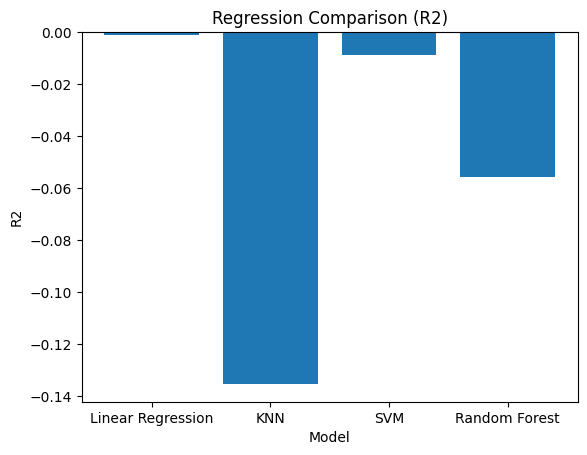

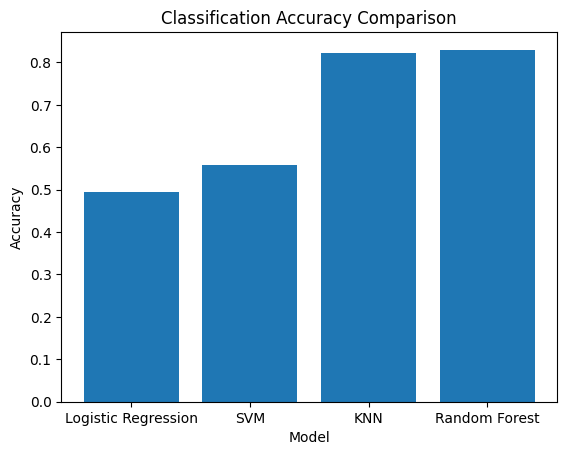

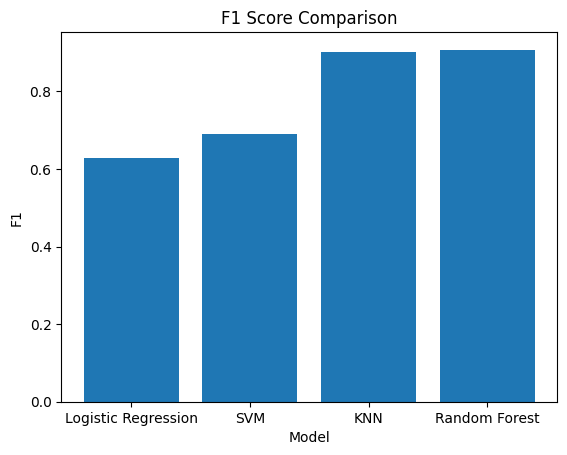

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier


df = pd.read_csv("/content/electric_vehicle_analytics CHANGED.csv")

print("\n===== DATA PREVIEW =====")
print(df.head())


print("\n===== DATA INFO =====")
print(df.info())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\n===== STATISTICS =====")
print(df.describe())

df.drop(columns=["Vehicle_ID"], errors="ignore", inplace=True)
df.drop(columns=["Make", "Model", "Vehicle_Type"], errors="ignore", inplace=True)

X = df[[
    "Charge_Cycles",
    "Temperature_C",
    "Mileage_km",
    "Battery_Capacity_kWh",
    "Energy_Consumption_kWh_per_100km"
]]

y_reg = df["Battery_Health_%"]

df["Health_Class"] = (df["Battery_Health_%"] > 75).astype(int)
y_clf = df["Health_Class"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)


reg_models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=7),
    "SVM": SVR(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42)
}

reg_results = []

for name, model in reg_models.items():
    if name in ["KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    reg_results.append([
        name,
        r2_score(y_test, pred),
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred))
    ])

reg_df = pd.DataFrame(reg_results, columns=["Model", "R2", "MAE", "RMSE"])

print("\n===== REGRESSION MATRIX =====")
print(reg_df)


clf_models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced'),
    "SVM": SVC(class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced')
}

clf_results = []

for name, model in clf_models.items():
    model.fit(Xc_train_scaled, yc_train)
    pred = model.predict(Xc_test_scaled)

    clf_results.append([
        name,
        accuracy_score(yc_test, pred),
        precision_score(yc_test, pred, zero_division=0),
        recall_score(yc_test, pred, zero_division=0),
        f1_score(yc_test, pred, zero_division=0)
    ])

clf_df = pd.DataFrame(clf_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])

print("\n===== CLASSIFICATION MATRIX =====")
print(clf_df)


plt.figure()
plt.bar(reg_df["Model"], reg_df["R2"])
plt.title("Regression Comparison (R2)")
plt.xlabel("Model")
plt.ylabel("R2")
plt.show()

plt.figure()
plt.bar(clf_df["Model"], clf_df["Accuracy"])
plt.title("Classification Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

plt.figure()
plt.bar(clf_df["Model"], clf_df["F1"])
plt.title("F1 Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1")
plt.show()

